In [1]:
%run init_notebook.py


Module aliases imported by init_notebook.py:
--------------------------------------------
import numpy as np

import pandas as pd

import statsmodels.formula.api as smf

import pymc as pm

import xarray as xr

import arviz as az

import utils as utils

from scipy import stats as stats

from matplotlib import pyplot as plt

Watermark:
----------
Last updated: 2026-01-07T16:37:21.747819+04:00

Python implementation: CPython
Python version       : 3.10.18
IPython version      : 8.15.0

Compiler    : Clang 20.1.4 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

pymc       : 5.8.0
scipy      : 1.11.2
arviz      : 0.16.1
statsmodels: 0.14.0
matplotlib : 3.7.2
xarray     : 2023.8.0
numpy      : 1.24.4
pandas     : 2.1.0



In [2]:
from scipy.special import factorial


def beta_posterior(n_W: int, n_L: int, p: float) -> float:
    """Calculates the beta posterior over proportions `p` given a set of
    `N_W` water and `N_L` land observations
    """
    return factorial(n_W + n_L + 1) / (factorial(n_W) * factorial(n_L)) * p ** n_W * (1-p) ** n_L

In [57]:
# Tossing the globe

resolution = 1000
observations = "WLWWWLWLW"
n_W = len(observations.replace("L", ""))
n_L = len(observations) - n_W
proportions = np.linspace(0, 1, resolution)

In [58]:
posterior = np.array([beta_posterior(n_W, n_L, p) for p in proportions])
posterior

array([0.00000000e+00, 8.42522516e-16, 5.37595149e-14, 6.10513730e-13,
       3.41994469e-12, 1.30067583e-11, 3.87208730e-11, 9.73448877e-11,
       2.16247342e-10, 4.37069531e-10, 8.19933757e-10, 1.44816096e-09,
       2.43348586e-09, 3.92175763e-09, 6.09911466e-09, 9.19862134e-09,
       1.35073558e-08, 1.93739370e-08, 2.72164793e-08, 3.75309645e-08,
       5.09000186e-08, 6.80020844e-08, 8.96209758e-08, 1.16655807e-07,
       1.50131281e-07, 1.91208333e-07, 2.41195111e-07, 3.01558290e-07,
       3.73934701e-07, 4.60143278e-07, 5.62197295e-07, 6.82316898e-07,
       8.22941918e-07, 9.86744946e-07, 1.17664468e-06, 1.39581950e-06,
       1.64772131e-06, 1.93608960e-06, 2.26496573e-06, 2.63870739e-06,
       3.06200335e-06, 3.53988831e-06, 4.07775799e-06, 4.68138439e-06,
       5.35693116e-06, 6.11096926e-06, 6.95049258e-06, 7.88293390e-06,
       8.91618081e-06, 1.00585919e-05, 1.13190129e-05, 1.27067932e-05,
       1.42318019e-05, 1.59044450e-05, 1.77356813e-05, 1.97370396e-05,
      

In [59]:
posterior_pairs = list(zip(proportions, posterior))
posterior_pairs


[(0.0, 0.0),
 (0.001001001001001001, 8.42522515777267e-16),
 (0.002002002002002002, 5.375951486879621e-14),
 (0.003003003003003003, 6.10513730374341e-13),
 (0.004004004004004004, 3.4199446889566787e-12),
 (0.005005005005005005, 1.3006758337669354e-11),
 (0.006006006006006006, 3.8720872953185005e-11),
 (0.007007007007007007, 9.734488773057231e-11),
 (0.008008008008008008, 2.162473416952935e-10),
 (0.009009009009009009, 4.3706953146039585e-10),
 (0.01001001001001001, 8.199337569283328e-10),
 (0.011011011011011011, 1.448160964306738e-09),
 (0.012012012012012012, 2.4334858557697874e-09),
 (0.013013013013013013, 3.921757634751513e-09),
 (0.014014014014014014, 6.0991146552046046e-09),
 (0.015015015015015015, 9.198621342197785e-09),
 (0.016016016016016016, 1.3507355849956905e-08),
 (0.017017017017017015, 1.9373937021879247e-08),
 (0.018018018018018018, 2.7216479315167544e-08),
 (0.01901901901901902, 3.753096445053917e-08),
 (0.02002002002002002, 5.090001864496807e-08),
 (0.02102102102102102, 

Text(0, 0.5, 'Posterior density')

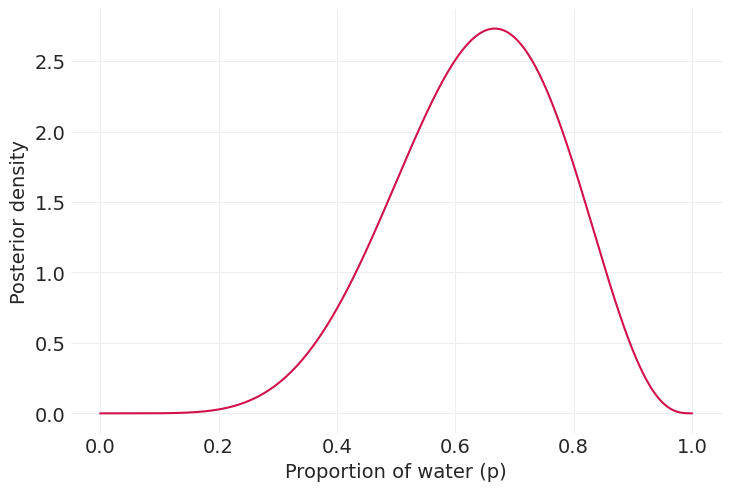

In [60]:
plt.plot(proportions, posterior)
plt.xlabel("Proportion of water (p)")
plt.ylabel("Posterior density")


In [61]:
dx = proportions[1] - proportions[0]
posterior /= np.sum(posterior * dx)  # normalize

cdf = np.cumsum(posterior * dx)

lower = proportions[np.searchsorted(cdf, 0.025)]
upper = proportions[np.searchsorted(cdf, 0.975)]

In [62]:
print(lower)
print(upper)



0.34734734734734735
0.8788788788788788


## There is a 95% posterior probability that the true proportion of water on the globe lies between approximately 0.35 and 0.88.

In [63]:
mean = np.sum(proportions * posterior * dx)
variance = np.sum((proportions - mean)**2 * posterior * dx)
std = np.sqrt(variance)


In [64]:
print(variance)
print(std)
print(mean)

0.019283746557267605
0.13886593015303503
0.636363636366192


# Why the mean ≠ 0.56 

> Mode (MAP) ≈ 0.56 → most plausible single value

> Mean ≈ 0.64 → average under uncertainty

> Slight right skew pulls the mean upward



In [65]:
proportions[np.argmax(posterior)]

0.6666666666666666

### “The posterior mean of the water proportion is approximately 0.64 with a posterior standard deviation of about 0.14, indicating substantial uncertainty. A 95% credible interval ranges from roughly 0.35 to 0.88

In [ ]:
# lets try book way step by step

In [1]:
from scipy.stats import binom

binom.pmf(6, 9, 0.5)
#“This computes the probability of observing exactly 6 successes in 9 trials, assuming each trial has a fixed success probability of 0.5.”
#P(W=6∣n=9,p=0.5)

0.16406250000000003

In [ ]:
#  “If the true probability of water were 0.5, there is a 0.16 (16%) probability of observing exactly 6 water outcomes in 9 tosses.”
# Likelihood is about surprise:

# “If p = 0.5 were true, seeing 6 waters in 9 tosses would not be very surprising.”

# That’s exactly what 0.16 means.

# OR
#A likelihood value of 0.16 means the observed data would occur about 16% of the time if the hypothesized model were true.

# Simple Grid Approximation Below for intution

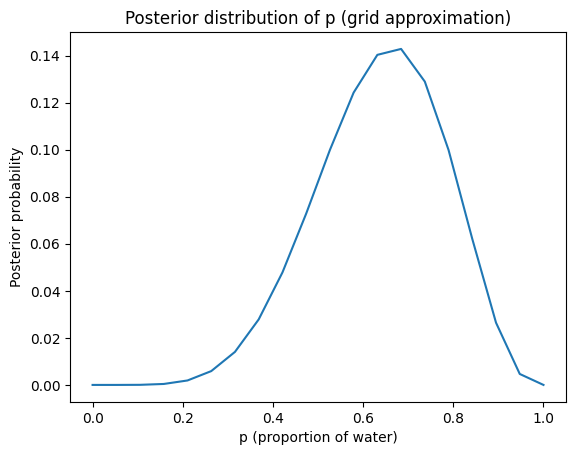

In [7]:
import numpy as np
from scipy.stats import binom

# define grid
p_grid = np.linspace(0, 1, 20)

# define prior (uniform)
prior = np.ones_like(p_grid)

# compute likelihood at each value in grid
# dbinom(6, size=9, prob=p_grid)  <->  binom.pmf(6, n=9, p=p_grid)
likelihood = binom.pmf(6, n=9, p=p_grid)

# compute product of likelihood and prior (unnormalized posterior)
unstd_posterior = likelihood * prior

# standardize posterior so it sums to 1
posterior = unstd_posterior / unstd_posterior.sum()

# optional: pair them like in the book
posterior_pairs = list(zip(p_grid, posterior))

p_grid, posterior, posterior_pairs[:20]


import matplotlib.pyplot as plt

# your data
p = [x[0] for x in posterior_pairs]
posterior = [x[1] for x in posterior_pairs]

plt.plot(p, posterior)
plt.xlabel("p (proportion of water)")
plt.ylabel("Posterior probability")
plt.title("Posterior distribution of p (grid approximation)")
plt.show()



In [10]:
likelihood

array([0.00000000e+00, 1.51814898e-06, 8.18509295e-05, 7.77292279e-04,
       3.59857537e-03, 1.11609461e-02, 2.66829865e-02, 5.29210991e-02,
       9.08269760e-02, 1.38341326e-01, 1.89768623e-01, 2.36114658e-01,
       2.66611252e-01, 2.71400562e-01, 2.45005089e-01, 1.89768623e-01,
       1.17918118e-01, 5.02667021e-02, 8.85384487e-03, 0.00000000e+00])

#### Inference (How to Read the Posterior)

> “Given the observed data and the model, about **14.3% of my total belief** is concentrated at a water proportion of **68.4%**.”

- This is **not** “the probability that \(p = 0.684\) exactly.”
- It **is** the probability mass assigned to a **small interval around 0.684**.
- Each row in the grid is a **hypothesis about reality**, weighted by plausibility.

---

### Conceptual visualization

- \(p\) on the **x-axis**
- posterior probability on the **y-axis**
- the **shape of the curve** = your belief after seeing the data

---

### Most plausible value (MAP)

- Look for the **peak** (maximum posterior).
- Peak near:

\[
p \approx 0.68
\]

**Inference:**  
The most plausible proportion of water on Earth is about **68%**.

---

### Uncertainty (where most mass lies)

Most posterior probability mass is concentrated roughly between:

\[
0.4 \;\lesssim\; p \;\lesssim\; 0.85
\]

**Inference:**  
There is **substantial uncertainty** — many values of \(p\) remain plausible.

---

### Probability statements about hypotheses

#### Is Earth more water than land?

Add posterior probabilities where:

\[
p > 0.5
\]

\[
\Pr(p > 0.5 \mid \text{data}) \approx 0.8
\]

**Inference:**  
There is about an **80% chance** Earth is mostly water.

---

#### Is water coverage between 60% and 80%?

Add posterior mass where:

\[
0.6 < p < 0.8
\]

**Inference:**  
Roughly **half of our belief** lies in this range.

---

### Prediction: next globe toss

\[
\Pr(\text{water next})
=
\sum_i p_i \Pr(p_i \mid \text{data})
\approx 0.62
\]

**Inference:**  
If we toss the globe again, there is about a **62% chance** it lands on water.

---

### Correct Bayesian language


✅ “The most plausible value of \(p\) is around 0.68.”  
✅ “There is a 90% probability that \(p\) lies in this interval.”

❌ “The probability that \(p = 0.68\).”


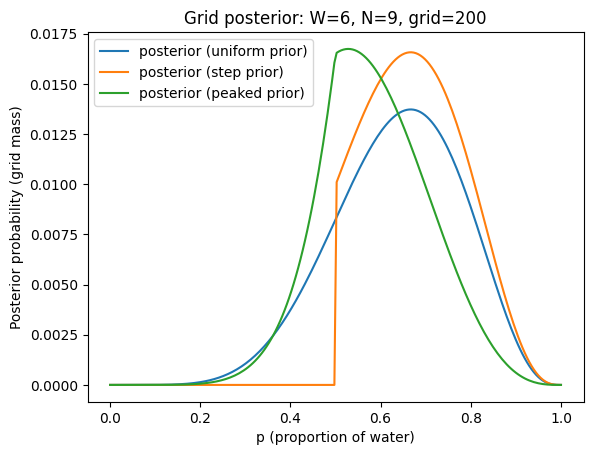

uniform prior | mean=0.636, MAP=0.668, ETI95%=[0.347, 0.879]
step    prior | mean=0.681, MAP=0.668, ETI95%=[0.513, 0.884]
peaked  prior | mean=0.586, MAP=0.528, ETI95%=[0.362, 0.829]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

def grid_posterior(W=6, N=9, grid_points=20, prior_type="uniform"):
    # grid
    p_grid = np.linspace(0, 1, grid_points)

    # priors (unnormalized is fine; we'll normalize later)
    if prior_type == "uniform":
        prior = np.ones_like(p_grid)

    elif prior_type == "step":  # R: ifelse(p_grid < 0.5, 0, 1)
        prior = np.where(p_grid < 0.5, 0.0, 1.0)

    elif prior_type == "peaked":  # R: exp(-5*abs(p_grid - 0.5))
        prior = np.exp(-5.0 * np.abs(p_grid - 0.5))

    else:
        raise ValueError("prior_type must be one of: 'uniform', 'step', 'peaked'")

    # likelihood
    likelihood = binom.pmf(W, n=N, p=p_grid)

    # posterior ∝ prior * likelihood
    unstd_post = prior * likelihood
    posterior = unstd_post / unstd_post.sum()

    return p_grid, prior / prior.sum() if prior.sum() > 0 else prior, likelihood, posterior


def summarize_posterior(p_grid, posterior):
    # posterior mean
    mean = np.sum(p_grid * posterior)

    # MAP (grid point with max posterior mass)
    map_p = p_grid[np.argmax(posterior)]

    # equal-tail interval (grid-based)
    cdf = np.cumsum(posterior)
    lo = p_grid[np.searchsorted(cdf, 0.025)]
    hi = p_grid[np.searchsorted(cdf, 0.975)]

    return mean, map_p, (lo, hi)


# Run for the three priors
W, N, grid_points = 6, 9, 200  # try 20 to match book; 200 looks smoother
priors = ["uniform", "step", "peaked"]

results = {}
for pr in priors:
    p_grid, prior, likelihood, posterior = grid_posterior(W, N, grid_points, pr)
    results[pr] = (p_grid, prior, posterior)

# Plot posteriors
plt.figure()
for pr in priors:
    p_grid, prior, posterior = results[pr]
    plt.plot(p_grid, posterior, label=f"posterior ({pr} prior)")
plt.xlabel("p (proportion of water)")
plt.ylabel("Posterior probability (grid mass)")
plt.title(f"Grid posterior: W={W}, N={N}, grid={grid_points}")
plt.legend()
plt.show()

# Print summaries
for pr in priors:
    p_grid, prior, posterior = results[pr]
    mean, map_p, (lo, hi) = summarize_posterior(p_grid, posterior)
    print(f"{pr:7s} prior | mean={mean:.3f}, MAP={map_p:.3f}, ETI95%=[{lo:.3f}, {hi:.3f}]")


# Quadratic Approximation

In [13]:
import numpy as np
from scipy.stats import binom, norm
from scipy.optimize import minimize

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
# Observed data:
#   W = number of "water" outcomes
#   L = number of "land" outcomes
# Total trials N = W + L
#
# This matches the R code:
#   data = list(W = 6, L = 3)
# ------------------------------------------------------------
W, L = 6, 3
N = W + L


def log_posterior(p: float) -> float:
    """
    Log-posterior function for p = probability of water.

    Model:
      W ~ Binomial(N, p)
      p ~ Uniform(0, 1)

    Since the prior is uniform on (0, 1), the log-prior is constant
    and does not affect the shape of the posterior. We only need
    to enforce the bounds 0 < p < 1.

    Parameters
    ----------
    p : float
        Candidate value of the probability of water.

    Returns
    -------
    float
        Log-posterior value (log-likelihood + log-prior).
        Returns -inf for invalid p outside (0, 1).
    """
    # Enforce parameter bounds implied by the prior
    if p <= 0.0 or p >= 1.0:
        return -np.inf

    # Log-likelihood of observing W successes in N trials
    # given success probability p
    return binom.logpmf(W, n=N, p=p)
    # (+ 0 for uniform prior)


def find_map(x0=0.5) -> float:
    """
    Find the MAP (maximum a posteriori) estimate of p.

    MAP = value of p that maximizes the posterior distribution.
    With a uniform prior, this is also the MLE.

    We use numerical optimization because this generalizes
    to models where an analytic solution is not available.

    Parameters
    ----------
    x0 : float
        Initial guess for p (starting point of the optimizer).

    Returns
    -------
    float
        MAP estimate of p.
    """
    res = minimize(
        fun=lambda x: -log_posterior(x[0]),  # minimize negative log-posterior
        x0=np.array([x0]),
        bounds=[(1e-9, 1 - 1e-9)]            # keep p inside (0,1)
    )

    if not res.success:
        raise RuntimeError(res.message)

    return float(res.x[0])


def second_derivative(f, x, eps=1e-6) -> float:
    """
    Numerically approximate the second derivative f''(x)
    using a central finite difference.

    This measures the *curvature* of f at x.

    In quadratic (Laplace) approximation:
      - High curvature  -> narrow posterior (low uncertainty)
      - Low curvature   -> wide posterior (high uncertainty)

    Parameters
    ----------
    f : callable
        Function whose second derivative is approximated.
    x : float
        Point at which to evaluate the second derivative.
    eps : float
        Small step size for finite difference.

    Returns
    -------
    float
        Approximation of the second derivative f''(x).
    """
    return (f(x + eps) - 2*f(x) + f(x - eps)) / (eps**2)


# ------------------------------------------------------------
# QUADRATIC (LAPLACE) APPROXIMATION
# ------------------------------------------------------------

# 1) Find the MAP (posterior mode)
#    For this model, it should be close to W / N = 6 / 9
p_map = find_map(x0=W / N)

# 2) Compute curvature of log-posterior at the MAP
#    The negative second derivative is the local precision
curv = -second_derivative(log_posterior, p_map)

# Convert curvature into variance and standard deviation
var = 1.0 / curv
sd = np.sqrt(var)

# 3) Approximate the posterior as a Normal distribution
#    centered at the MAP with variance derived from curvature
qa = norm(loc=p_map, scale=sd)

# ------------------------------------------------------------
# SUMMARY (similar to rethinking::precis)
# ------------------------------------------------------------

# For a Normal approximation:
#   mean == MAP
mean = qa.mean()
interval_95 = qa.interval(0.95)

print(f"MAP (quap mean) = {p_map:.6f}")
print(f"SD             = {sd:.6f}")
print(f"95% interval   = [{interval_95[0]:.6f}, {interval_95[1]:.6f}]")


MAP (quap mean) = 0.666667
SD             = 0.157135
95% interval   = [0.358688, 0.974645]


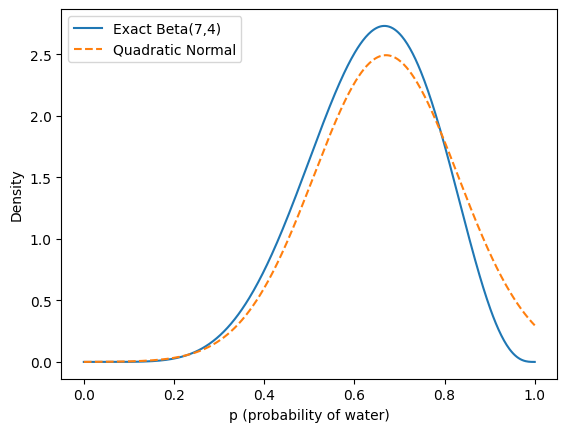

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

# Observed data:
# 6 water outcomes and 3 land outcomes
W, L = 6, 3

# Create a grid of possible values for p (probability of water)
x = np.linspace(0, 1, 500)

# -------------------------------------------------------------------
# Exact analytical posterior
# -------------------------------------------------------------------
# With a Uniform(0,1) prior, the Binomial likelihood is conjugate,
# so the posterior can be computed exactly:
#
#   p | data ~ Beta(W + 1, L + 1)
#
# This curve represents the TRUE posterior distribution.
exact = beta.pdf(x, W + 1, L + 1)

# -------------------------------------------------------------------
# Quadratic (Laplace) approximation
# -------------------------------------------------------------------
# Near its maximum, the posterior distribution looks like a bell curve.
# The quadratic approximation replaces the true posterior with a Normal
# distribution that matches:
#   - the location of the peak (MAP ≈ 0.67)
#   - the local width of the peak (sd ≈ 0.16)
#
# This curve is an approximation, not the exact posterior.
quad = norm.pdf(x, 0.67, 0.16)

# -------------------------------------------------------------------
# Goal of this comparison
# -------------------------------------------------------------------
# The purpose of plotting these two curves together is to:
#
# 1) Show that different methods (exact vs approximation) are trying
#    to describe the same posterior distribution.
# 2) Demonstrate when quadratic approximation works well:
#    - unimodal posterior
#    - moderate skew
#    - MAP not near the boundaries (0 or 1)
# 3) Reveal its limitations:
#    - ignores the hard bounds on p
#    - cannot capture skewness perfectly
#
# This example builds intuition for why fast approximations (like quap)
# are useful, but also why we must be cautious when using them.
# -------------------------------------------------------------------

# Plot comparison
plt.plot(x, exact, label="Exact Beta(7,4)")
plt.plot(x, quad, "--", label="Quadratic Normal")
plt.xlabel("p (probability of water)")
plt.ylabel("Density")
plt.legend()
plt.show()


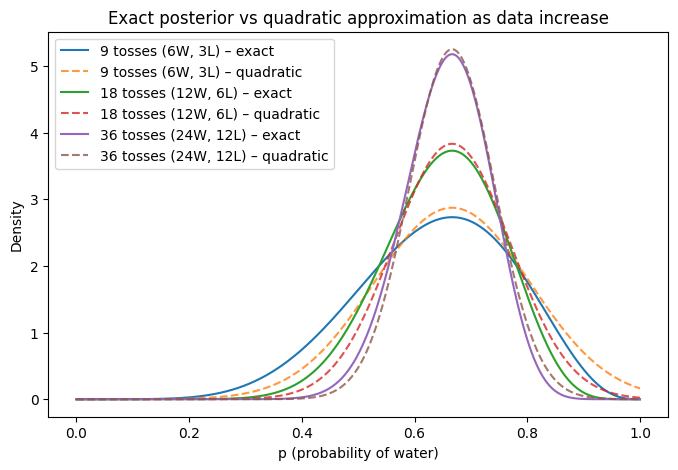

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

# Grid of possible p values (probability of water)
x = np.linspace(0, 1, 500)

# -------------------------------------------------------
# Three datasets with the same water fraction (2/3)
# -------------------------------------------------------
# Left:   9 tosses  ->  6 water, 3 land
# Middle: 18 tosses -> 12 water, 6 land
# Right:  36 tosses -> 24 water, 12 land
datasets = [
    (6, 3, "9 tosses (6W, 3L)"),
    (12, 6, "18 tosses (12W, 6L)"),
    (24, 12, "36 tosses (24W, 12L)")
]

plt.figure(figsize=(8, 5))

for W, L, label in datasets:
    # ---------------------------------------------------
    # Exact analytical posterior
    # ---------------------------------------------------
    # With a Uniform(0,1) prior, the posterior is exactly:
    #   p | data ~ Beta(W + 1, L + 1)
    exact = beta.pdf(x, W + 1, L + 1)

    # ---------------------------------------------------
    # Quadratic (Laplace) approximation
    # ---------------------------------------------------
    # For a Beta(a, b) posterior:
    #   MAP ≈ (a - 1) / (a + b - 2) = W / (W + L)
    #   Variance ≈ ab / [(a + b)^2 (a + b + 1)]
    a, b = W + 1, L + 1
    map_p = W / (W + L)
    var = (a * b) / ((a + b)**2 * (a + b + 1))
    sd = np.sqrt(var)

    quad = norm.pdf(x, map_p, sd)

    # Plot exact posterior (solid) and quadratic approximation (dashed)
    plt.plot(x, exact, label=f"{label} – exact")
    plt.plot(x, quad, "--", alpha=0.8, label=f"{label} – quadratic")

# -------------------------------------------------------
# Goal of this comparison
# -------------------------------------------------------
# The goal is to compare:
#   - the true posterior (Beta)
#   - a fast local approximation (Normal)
#
# This shows that:
# 1) As data increase, both curves become narrower (less uncertainty).
# 2) The quadratic approximation improves with more data.
# 3) With small datasets, the Normal approximation misses skewness
#    and ignores the [0,1] bounds on p.
# -------------------------------------------------------

plt.xlabel("p (probability of water)")
plt.ylabel("Density")
plt.title("Exact posterior vs quadratic approximation as data increase")
plt.legend()
plt.show()
